In [1]:
import sys
import os

# Get the directory containing the notebook
NOTEBOOK_DIR = os.getcwd()

# Compute project root (go up one level)
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))

# Add project root to path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

In [2]:
import scanpy as sc
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt

In [3]:
from src.data.umi_data import UMIVaeDataset
from src.celluntangler import utils
from src.celluntangler.models import Trainer
from src.celluntangler.models.nb_vae import NBVAE
from src.visualization.helpers import split_embeddings
from src.visualization.visualization_functions import visualize_poincare_from_lorentz, visualize_embedding, visualize_2d

/Users/jeromecho/Library/CloudStorage/OneDrive-Personal/Thesis/thesis/code/venvs/CellUntangler/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
# TODO - change path to actual data you care about
# TODO - debug getting HVG genes working with annotated dataframe
adata = sc.read_h5ad("../../../data/HGSOC/ALL_CELLS/all_cells_1p.h5ad")

In [6]:
adata = adata.raw.to_adata()

In [10]:
adata.obs["Phase"] = (adata.obs["Phase"].astype("category").cat.reorder_categories(["G2M", "S", "G1"], ordered=True))

In [24]:
adata.var["feature_name"]

ENSG00000243485        MIR1302-2HG
ENSG00000186092              OR4F5
ENSG00000238009    ENSG00000238009
ENSG00000239945    ENSG00000239945
ENSG00000241599    ENSG00000241599
                        ...       
ENSG00000276345    ENSG00000276345
ENSG00000277856    ENSG00000277856
ENSG00000275063    ENSG00000275063
ENSG00000271254    ENSG00000271254
ENSG00000268674    ENSG00000268674
Name: feature_name, Length: 31815, dtype: category
Categories (31800, object): ['A1BG', 'A1BG-AS1', 'A1CF', 'A2M', ..., 'ZYG11B', 'ZYX', 'ZZEF1', 'ZZZ3']

In [25]:
adata.var

,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000243485,MIR1302-2HG,NCBITaxon:9606,gene,623,lncRNA
ENSG00000186092,OR4F5,NCBITaxon:9606,gene,2618,protein_coding
ENSG00000238009,ENSG00000238009,NCBITaxon:9606,gene,629,lncRNA
ENSG00000239945,ENSG00000239945,NCBITaxon:9606,gene,1319,lncRNA
ENSG00000241599,ENSG00000241599,NCBITaxon:9606,gene,457,lncRNA
...,...,...,...,...,...
ENSG00000276345,ENSG00000276345,NCBITaxon:9606,gene,740,protein_coding
ENSG00000277856,ENSG00000277856,NCBITaxon:9606,gene,294,protein_coding
ENSG00000275063,ENSG00000275063,NCBITaxon:9606,gene,351,protein_coding
ENSG00000271254,ENSG00000271254,NCBITaxon:9606,gene,2922,protein_coding


In [41]:
import pandas as pd
import numpy as np


gene = "MKI67"


# Find column index of the gene
gene_idx = adata.var.index[adata.var["feature_name"] == gene]


if len(gene_idx) == 0:
    raise KeyError(f"Gene '{gene}' not found in adata.var['feature_name']")
if len(gene_idx) > 1:
    raise ValueError(f"Gene '{gene}' appears multiple times in adata.var['feature_name']")


gene_idx = gene_idx[0]


# Extract expression
expr = adata.X[:, adata.var.index.get_loc(gene_idx)]


# Convert to 1D numpy array
if hasattr(expr, "toarray"):
    expr = expr.toarray().ravel()
else:
    expr = np.asarray(expr).ravel()

In [42]:
df = pd.DataFrame({
"Phase": adata.obs["Phase"].values,
"MKI67_expr": expr
})

In [43]:
summary = (
df
.groupby("Phase")["MKI67_expr"]
.agg(
mean="mean",
median="median",
std="std",
n="count"
)
)


summary

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_63880/2221975809.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["MKI67_expr"]


,mean,median,std,n
Phase,,,,
G2M,2.977438,0.0,6.475361,1374
S,0.454096,0.0,1.964610,1819
G1,0.018270,0.0,0.191042,7006


In [45]:
# Keep only cells where ACYP1 expression > 0
df_nonzero = df[df["MKI67_expr"] > 0]


# Generate summary ignoring zero-expression cells
summary = (
df_nonzero
.groupby("Phase")["MKI67_expr"]
.agg(
mean="mean",
median="median",
std="std",
n="count"
)
)


summary

/var/folders/2z/f9h5sjqj6m9dz0ljc7yy_plw0000gn/T/ipykernel_63880/3792137104.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("Phase")["MKI67_expr"]


,mean,median,std,n
Phase,,,,
G2M,7.704331,5.0,8.493347,531
S,3.720721,2.0,4.420584,222
G1,1.319588,1.0,0.963353,97


<Figure size 640x480 with 0 Axes>

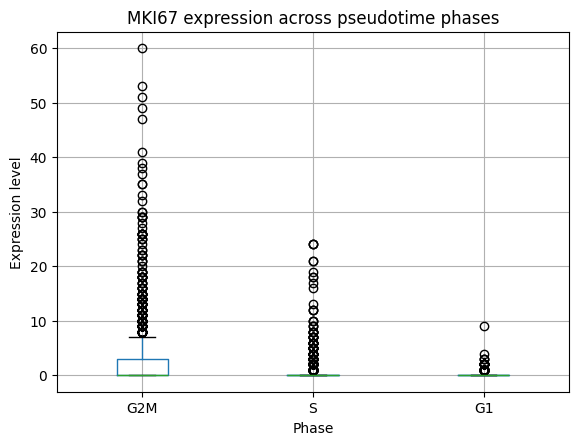

In [48]:
import matplotlib.pyplot as plt


plt.figure()
df.boxplot(column="MKI67_expr", by="Phase")
plt.suptitle("")
plt.title("MKI67 expression across pseudotime phases")
plt.ylabel("Expression level")
plt.xlabel("Phase")
plt.show()